# Shadow Residual v59: retained-orientation / eta shadow audit

No file IO. Each code cell runs one claim, prints PASS/FAIL, reports numeric checks, and emits one inline figure.

PASS: eta positive-half coefficient check to t^1600
mismatches=0 nonzero_terms=13
first terms: [(1, Fraction(1, 24), 1), (25, Fraction(25, 24), -1), (49, Fraction(49, 24), -1), (121, Fraction(121, 24), 1), (169, Fraction(169, 24), 1), (289, Fraction(289, 24), -1), (361, Fraction(361, 24), -1), (529, Fraction(529, 24), 1), (625, Fraction(625, 24), 1), (841, Fraction(841, 24), -1)]


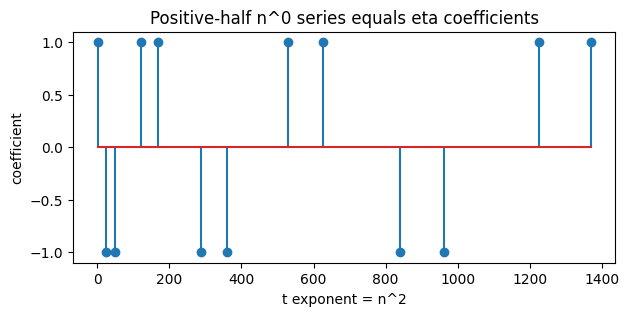

In [1]:

import sympy as sp
import matplotlib.pyplot as plt
from fractions import Fraction

def chi12(n: int) -> int:
    r = n % 12
    if r in (1, 11):
        return 1
    if r in (5, 7):
        return -1
    return 0

def positive_half_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c
        n += 1
    return d

def shadow_residual_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c*n
        n += 1
    return d

def eta_product_coeffs(max_exp: int) -> dict[int, int]:
    t = sp.Symbol('t')
    expr = t
    max_m = max_exp // 24 + 2
    for m in range(1, max_m + 1):
        expr = sp.series(expr * (1 - t**(24*m)), t, 0, max_exp + 1).removeO().expand()
    poly = sp.Poly(expr, t)
    return {int(exp[0]): int(coeff) for exp, coeff in poly.terms() if exp[0] <= max_exp and coeff != 0}

max_exp = 1600
pos = positive_half_coeffs(max_exp)
eta = eta_product_coeffs(max_exp)
all_exps = sorted(set(pos) | set(eta))
mismatches = [(e, pos.get(e, 0), eta.get(e, 0)) for e in all_exps if pos.get(e, 0) != eta.get(e, 0)]
status = 'PASS' if len(mismatches) == 0 else 'FAIL'
print(f'{status}: eta positive-half coefficient check to t^{max_exp}')
print(f'mismatches={len(mismatches)} nonzero_terms={len(pos)}')
print('first terms:', [(e, Fraction(e,24), pos[e]) for e in sorted(pos)[:10]])
xs = [e for e,_ in sorted(pos.items())]
ys = [c for _,c in sorted(pos.items())]
plt.figure(figsize=(7, 3))
plt.stem(xs, ys)
plt.xlabel('t exponent = n^2')
plt.ylabel('coefficient')
plt.title('Positive-half n^0 series equals eta coefficients')
plt.show()


PASS: scalar bilateral Jacobi derivative cancels on symmetric windows
[(1, 0), (5, 0), (12, 0), (37, 0), (89, 0), (144, 0)]


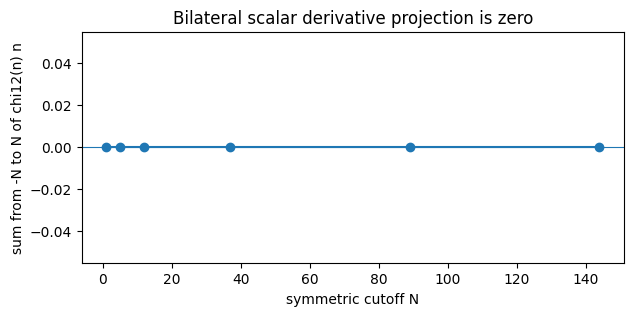

In [2]:

import sympy as sp
import matplotlib.pyplot as plt
from fractions import Fraction

def chi12(n: int) -> int:
    r = n % 12
    if r in (1, 11):
        return 1
    if r in (5, 7):
        return -1
    return 0

def positive_half_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c
        n += 1
    return d

def shadow_residual_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c*n
        n += 1
    return d

def eta_product_coeffs(max_exp: int) -> dict[int, int]:
    t = sp.Symbol('t')
    expr = t
    max_m = max_exp // 24 + 2
    for m in range(1, max_m + 1):
        expr = sp.series(expr * (1 - t**(24*m)), t, 0, max_exp + 1).removeO().expand()
    poly = sp.Poly(expr, t)
    return {int(exp[0]): int(coeff) for exp, coeff in poly.terms() if exp[0] <= max_exp and coeff != 0}

def bilateral_derivative_symmetric(max_n: int) -> int:
    return sum(chi12(n)*n for n in range(-max_n, max_n + 1))
Ns = [1, 5, 12, 37, 89, 144]
vals = [bilateral_derivative_symmetric(N) for N in Ns]
status = 'PASS' if all(v == 0 for v in vals) else 'FAIL'
print(f'{status}: scalar bilateral Jacobi derivative cancels on symmetric windows')
print(list(zip(Ns, vals)))
plt.figure(figsize=(7, 3))
plt.plot(Ns, vals, marker='o')
plt.axhline(0, linewidth=0.8)
plt.xlabel('symmetric cutoff N')
plt.ylabel('sum from -N to N of chi12(n) n')
plt.title('Bilateral scalar derivative projection is zero')
plt.show()


PASS: positive half n-weighted Shadow Residual is nonzero
first terms: [(1, Fraction(1, 24), 1), (25, Fraction(25, 24), -5), (49, Fraction(49, 24), -7), (121, Fraction(121, 24), 11), (169, Fraction(169, 24), 13), (289, Fraction(289, 24), -17), (361, Fraction(361, 24), -19), (529, Fraction(529, 24), 23), (625, Fraction(625, 24), 25), (841, Fraction(841, 24), -29)]


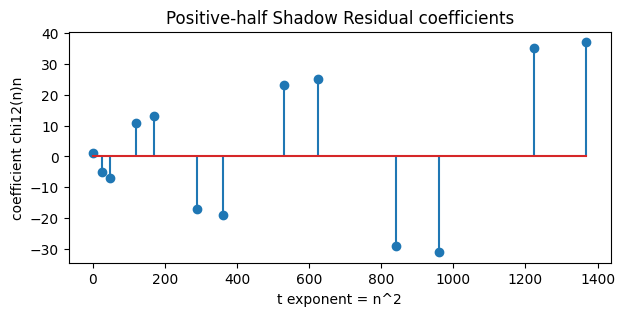

In [3]:

import sympy as sp
import matplotlib.pyplot as plt
from fractions import Fraction

def chi12(n: int) -> int:
    r = n % 12
    if r in (1, 11):
        return 1
    if r in (5, 7):
        return -1
    return 0

def positive_half_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c
        n += 1
    return d

def shadow_residual_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c*n
        n += 1
    return d

def eta_product_coeffs(max_exp: int) -> dict[int, int]:
    t = sp.Symbol('t')
    expr = t
    max_m = max_exp // 24 + 2
    for m in range(1, max_m + 1):
        expr = sp.series(expr * (1 - t**(24*m)), t, 0, max_exp + 1).removeO().expand()
    poly = sp.Poly(expr, t)
    return {int(exp[0]): int(coeff) for exp, coeff in poly.terms() if exp[0] <= max_exp and coeff != 0}

max_exp = 1600
R = shadow_residual_coeffs(max_exp)
status = 'PASS' if len(R) > 0 and R.get(1) == 1 and R.get(25) == -5 and R.get(49) == -7 else 'FAIL'
print(f'{status}: positive half n-weighted Shadow Residual is nonzero')
print('first terms:', [(e, Fraction(e,24), R[e]) for e in sorted(R)[:10]])
xs = [e for e,_ in sorted(R.items())]
ys = [c for _,c in sorted(R.items())]
plt.figure(figsize=(7, 3))
plt.stem(xs, ys)
plt.xlabel('t exponent = n^2')
plt.ylabel('coefficient chi12(n)n')
plt.title('Positive-half Shadow Residual coefficients')
plt.show()


PASS: bilateral n^0 theta is twice the positive-half eta series
mismatches=0 checked_terms=13


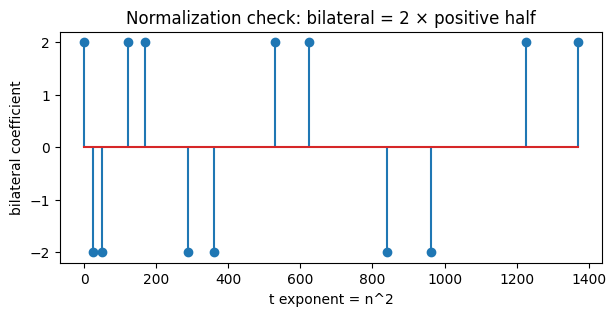

In [4]:

import sympy as sp
import matplotlib.pyplot as plt
from fractions import Fraction

def chi12(n: int) -> int:
    r = n % 12
    if r in (1, 11):
        return 1
    if r in (5, 7):
        return -1
    return 0

def positive_half_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c
        n += 1
    return d

def shadow_residual_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c*n
        n += 1
    return d

def eta_product_coeffs(max_exp: int) -> dict[int, int]:
    t = sp.Symbol('t')
    expr = t
    max_m = max_exp // 24 + 2
    for m in range(1, max_m + 1):
        expr = sp.series(expr * (1 - t**(24*m)), t, 0, max_exp + 1).removeO().expand()
    poly = sp.Poly(expr, t)
    return {int(exp[0]): int(coeff) for exp, coeff in poly.terms() if exp[0] <= max_exp and coeff != 0}

max_exp = 1600
pos = positive_half_coeffs(max_exp)
bilateral = {}
nmax = int(max_exp**0.5)
for n in range(-nmax, nmax + 1):
    if n == 0:
        continue
    c = chi12(n)
    if c and n*n <= max_exp:
        bilateral[n*n] = bilateral.get(n*n, 0) + c
mismatches = [(e, bilateral.get(e,0), 2*pos.get(e,0)) for e in set(bilateral) | set(pos) if bilateral.get(e,0) != 2*pos.get(e,0)]
status = 'PASS' if not mismatches else 'FAIL'
print(f'{status}: bilateral n^0 theta is twice the positive-half eta series')
print(f'mismatches={len(mismatches)} checked_terms={len(pos)}')
xs = [e for e,_ in sorted(pos.items())]
ys = [bilateral[e] for e in xs]
plt.figure(figsize=(7, 3))
plt.stem(xs, ys)
plt.xlabel('t exponent = n^2')
plt.ylabel('bilateral coefficient')
plt.title('Normalization check: bilateral = 2 × positive half')
plt.show()


PASS: two-orientation channel carries what scalar sum erases
residue plus minus scalar_sum: [(1, 1, -1, 0), (5, -5, 5, 0), (7, -7, 7, 0), (11, 11, -11, 0)]


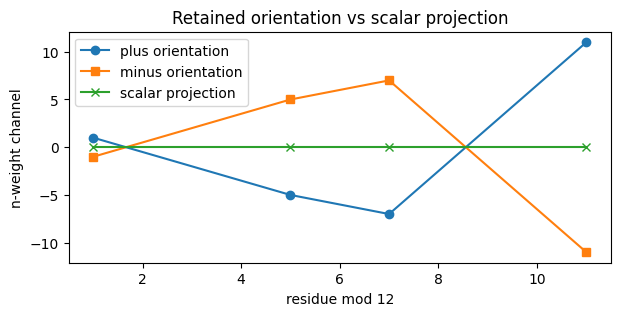

In [5]:

import sympy as sp
import matplotlib.pyplot as plt
from fractions import Fraction

def chi12(n: int) -> int:
    r = n % 12
    if r in (1, 11):
        return 1
    if r in (5, 7):
        return -1
    return 0

def positive_half_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c
        n += 1
    return d

def shadow_residual_coeffs(max_exp: int) -> dict[int, int]:
    d = {}
    n = 1
    while n*n <= max_exp:
        c = chi12(n)
        if c:
            d[n*n] = d.get(n*n, 0) + c*n
        n += 1
    return d

def eta_product_coeffs(max_exp: int) -> dict[int, int]:
    t = sp.Symbol('t')
    expr = t
    max_m = max_exp // 24 + 2
    for m in range(1, max_m + 1):
        expr = sp.series(expr * (1 - t**(24*m)), t, 0, max_exp + 1).removeO().expand()
    poly = sp.Poly(expr, t)
    return {int(exp[0]): int(coeff) for exp, coeff in poly.terms() if exp[0] <= max_exp and coeff != 0}

support = [1,5,7,11]
plus = [chi12(r)*r for r in support]
minus = [-chi12(r)*r for r in support]
sums = [a+b for a,b in zip(plus, minus)]
status = 'PASS' if all(s == 0 for s in sums) and plus != minus else 'FAIL'
print(f'{status}: two-orientation channel carries what scalar sum erases')
print('residue plus minus scalar_sum:', list(zip(support, plus, minus, sums)))
plt.figure(figsize=(7, 3))
plt.plot(support, plus, marker='o', label='plus orientation')
plt.plot(support, minus, marker='s', label='minus orientation')
plt.plot(support, sums, marker='x', label='scalar projection')
plt.xlabel('residue mod 12')
plt.ylabel('n-weight channel')
plt.title('Retained orientation vs scalar projection')
plt.legend()
plt.show()
